In [1]:
import pandas as pd
from data_preparation import Data_Preparation as dp
prep = dp()
df = prep.prepare_data_general()
X = df.drop(columns=['PumpTimeInSeconds','WaterLevel'])
y = df['PumpTimeInSeconds']
X

,Temperature,AirHumidity,SoilHumidity,LightIntensity,seconds_since_watering,OptimalTemperature,OptimalAirHumidity,OptimalSoilHumidity,OptimalLightIntensity
0,23.64,45.55,62.13,418.42,0.0,23.1,40.8,58.3,411.6
1,24.43,55.89,64.63,610.03,0.0,25.7,62.4,67.0,673.7
2,20.47,71.06,52.24,417.98,0.0,22.8,67.2,55.9,422.3
3,23.59,51.47,51.39,538.78,0.0,19.6,52.7,60.1,543.2
4,19.17,54.76,62.04,340.83,0.0,20.1,58.9,65.2,307.8
...,...,...,...,...,...,...,...,...,...
29995,20.72,33.62,48.41,547.89,18000.0,22.6,40.1,51.9,567.8
29996,20.75,49.92,61.38,442.05,10800.0,22.3,47.2,60.9,383.9
29997,24.07,43.74,54.93,446.14,86400.0,23.1,40.8,58.3,411.6
29998,17.06,46.90,70.00,543.10,21600.0,19.6,52.7,60.1,543.2


In [2]:
from sklearn.model_selection import  train_test_split
# Assuming X is your feature matrix and y is your target variable
# First split into training and temp (validation + test)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train,X_val,y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.20, random_state=42)
X_train

,Temperature,AirHumidity,SoilHumidity,LightIntensity,seconds_since_watering,OptimalTemperature,OptimalAirHumidity,OptimalSoilHumidity,OptimalLightIntensity
9922,19.77,48.70,53.03,325.08,36000.0,19.2,43.7,52.9,458.9
2156,20.34,61.36,66.31,441.15,57600.0,22.8,67.2,55.9,422.3
162,24.83,40.64,46.71,612.97,36000.0,22.6,40.1,51.9,567.8
1463,19.61,51.94,60.55,637.01,100800.0,20.1,47.3,70.4,722.4
5624,30.87,52.37,72.97,776.15,118800.0,25.7,62.4,67.0,673.7
...,...,...,...,...,...,...,...,...,...
21116,19.90,56.92,63.12,422.08,39600.0,19.6,52.7,60.1,543.2
1005,20.37,57.05,56.00,356.42,108000.0,19.6,52.7,60.1,543.2
27259,22.69,47.68,77.26,596.22,100800.0,24.3,46.7,78.3,657.6
19556,25.32,50.52,53.77,442.53,93600.0,22.3,47.2,60.9,383.9


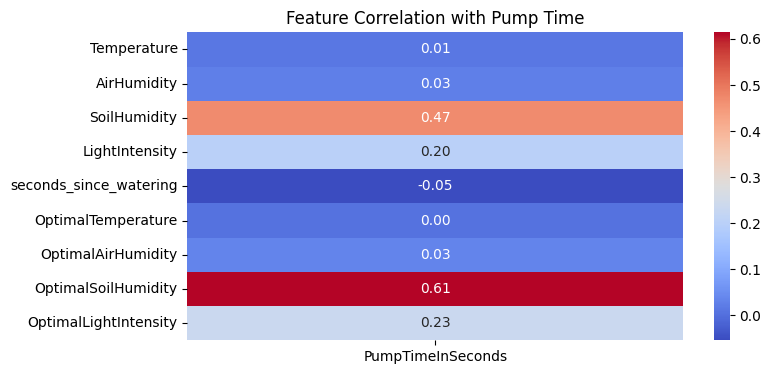

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# correlation of each feature with target
corr_series = X_train.corrwith(y_train)

plt.figure(figsize=(8, 4))
sns.heatmap(corr_series.to_frame(name='PumpTimeInSeconds'),
            annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation with Pump Time')
plt.show()

In [13]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)  # output — single number (pump seconds)
])

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    verbose=0
)

train_r2 = r2_score(y_train, model.predict(X_train_scaled))
val_r2   = r2_score(y_val,   model.predict(X_val_scaled))

print(f"Train set R²: {train_r2:.2f}")
print(f"Val set R²:   {val_r2:.2f}")

I0000 00:00:1778248878.079614   80272 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778248878.168848   80272 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778248882.647810   80272 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/workspace/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1778248883.378000   80272 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to 

600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 365us/step
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step
Train set R²: 0.44
Val set R²:   0.42
